# 4. 행렬과 행렬의 기본 연산

## 행렬은 표이면서 선형변환이다

- **배울 것**: 인덱싱, 특수 행렬, 원소별 곱과 행렬 곱, 전치와 대칭.
- $m\times n$ 행렬은 행이 $m$개, 열이 $n$개인 숫자 배열입니다. NumPy의 `shape`도 `(행, 열)` 순서입니다.
- `A[1,3]`은 두 번째 행·네 번째 열입니다. `A[:5,:5]`는 처음 5행·5열을 선택하며 끝 인덱스는 포함하지 않습니다.

## 같은 모양의 연산과 안쪽 차원이 맞는 연산

$$
(A+B)_{ij}=a_{ij}+b_{ij},\quad
(A\odot B)_{ij}=a_{ij}b_{ij},\quad
(AB)_{ij}=\sum_{k=1}^{n}a_{ik}b_{kj}
$$

- `A*B`는 원소별 곱입니다. `A@B`는 행렬 곱입니다.
- $A\in\mathbb R^{m\times n}$, $B\in\mathbb R^{n\times p}$이면 $AB\in\mathbb R^{m\times p}$입니다.
- $A=\begin{bmatrix}1&2\\3&4\end{bmatrix}$, $B=\begin{bmatrix}2&0\\1&2\end{bmatrix}$이면 $AB=\begin{bmatrix}4&4\\10&8\end{bmatrix}$입니다. 첫 원소 4는 $1\cdot2+2\cdot1$입니다.
- $A\mathbf x$는 A의 열들을 $\mathbf x$의 성분으로 가중합한 것입니다. 각 열은 좌표축의 단위벡터가 이동한 결과이기도 합니다.

## 자주 만나는 행렬과 전치

$$
AI=IA=A,\qquad (AB)^T=B^TA^T,\qquad S=S^T
$$

- 항등행렬 $I$는 변환을 하지 않습니다. 영행렬은 모든 벡터를 0으로 보냅니다.
- 대각행렬을 왼쪽에 곱하면 행을, 오른쪽에 곱하면 열을 각각 확대·축소합니다.
- $A+\lambda I$는 대각 원소만 바꿉니다. `A+lambda`는 모든 원소에 더하는 브로드캐스팅이므로 다릅니다.
- 전치는 행과 열을 바꾸며 곱의 순서도 뒤집습니다. 변환의 합성 순서를 거꾸로 추적하기 때문입니다.
- $(A+A^T)/2$는 대칭행렬이고 $A^TA$는 대칭 양의 준정부호 행렬입니다. 두 생성법의 성질이 완전히 같지는 않습니다.
- **주의**: NumPy 브로드캐스팅으로 계산이 성공해도 원하는 수학 연산이라는 보장은 없습니다. 먼저 `shape`를 확인하세요.

## 읽기 안내

- 이 글은 제공된 Python 예제를 바탕으로 새로 작성한 해설입니다. 연습문제의 질문은 코드에서 확인되는 학습 목표를 재구성했으며 책의 문제 원문을 옮긴 것이 아닙니다.
- 코드·실행 결과는 아래 순서로 연결됩니다. 앞 셀의 변수를 쓰므로 노트북은 처음부터 실행하세요.
- 난수 시드는 장마다 고정했습니다. 실행 시간과 마지막 소수 자릿수는 환경에 따라 달라질 수 있습니다.
- `1e-14` 같은 작은 잔차는 부동소수점 오차일 수 있습니다. 수학적 0과 컴퓨터의 정확한 0을 구분하세요.

## 실행 환경


In [1]:
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT / 'blog_linear_algebra'
DATA = ROOT / 'data'
ASSET = ROOT / 'assets' / 'ch04'
ASSET.mkdir(parents=True, exist_ok=True)
np.random.seed(20260929)
np.set_printoptions(precision=6, suppress=True, threshold=120)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 140, 'font.size': 12})
print('재현용 난수 시드:', 20260929)

재현용 난수 시드: 20260929


### 코드 04-01

- 원본: `original_py/LA4DS_ch04.py` 1–14행.
- **보완**: Markdown 호환을 위해 그림 출력을 PNG로 지정했습니다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# for null spaces
import scipy.linalg

# a pretty-looking matrix from scipy
from scipy.linalg import toeplitz


# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png') # print figures in svg format
plt.rcParams.update({'font.size':14}) # set global font size

### 코드 04-02

- 원본: `original_py/LA4DS_ch04.py` 16–18행.

In [3]:
v = np.array([[1,2,3]]).T # col vector
w = np.array([[10,20]])   # row vector
v + w

Out[3]: 
array([[11, 21],
       [12, 22],
       [13, 23]])


### 행렬을 색상으로 읽기

### 코드 04-03

- 원본: `original_py/LA4DS_ch04.py` 20–36행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

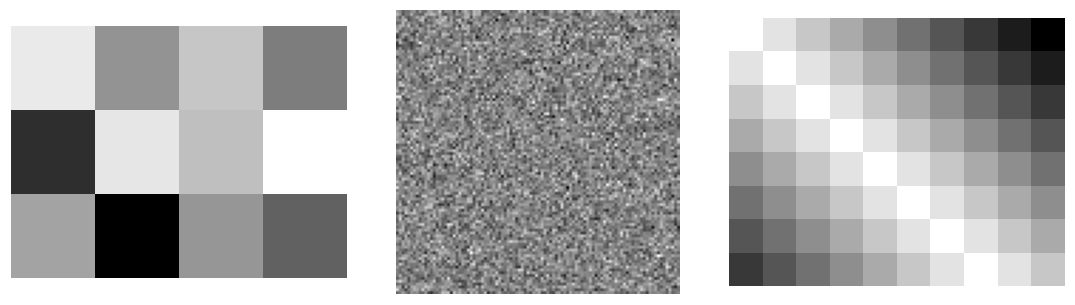

In [4]:
# create some matrices
A = np.random.randn(3,4)
B = np.random.randn(100,100)
C = -toeplitz(np.arange(8),np.arange(10))


# and show them as images
fig,axs = plt.subplots(1,3,figsize=(10,3))

axs[0].imshow(A,cmap='gray')
axs[1].imshow(B,cmap='gray')
axs[2].imshow(C,cmap='gray')

for i in range(3): axs[i].axis('off')
plt.tight_layout()
plt.savefig(ASSET / 'Figure_04_01.png',dpi=140)
plt.show()

### 행·열 슬라이싱

### 코드 04-04

- 원본: `original_py/LA4DS_ch04.py` 40–42행.

In [5]:
# create a matrix
A = np.reshape(np.arange(1,10),(3,3))
print(A)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


### 코드 04-05

- 원본: `original_py/LA4DS_ch04.py` 44–50행.

In [6]:
# get the n-th row

print( A[1,:] )

# note that to extract only one row, you don't need the column indices. 
print( A[1] )
# But that's potentially confusing, so I recommend avoiding that notation.

[4 5 6]
[4 5 6]


### 코드 04-06

- 원본: `original_py/LA4DS_ch04.py` 52–54행.

In [7]:
# get the n-th column
print( A[:,1] )
# Note that it prints out as a "row" even thought it's a column of the matrix

[2 5 8]


### 코드 04-07

- 원본: `original_py/LA4DS_ch04.py` 56–57행.

In [8]:
# multiple rows
A[0:2,:]

Out[8]: 
array([[1, 2, 3],
       [4, 5, 6]])


### 코드 04-08

- 원본: `original_py/LA4DS_ch04.py` 59–60행.

In [9]:
# multiple columns
A[:,1:]

Out[9]: 
array([[2, 3],
       [5, 6],
       [8, 9]])


### 코드 04-09

- 원본: `original_py/LA4DS_ch04.py` 62–79행.

In [10]:
## extracting a submatrix (multiple rows and cols)

# The goal here is to extract a submatrix from matrix A. Here's A:
# [[1 2 3]
#  [4 5 6]
#  [7 8 9]]

# And we want rows 0-1 and columns 0-1, thus:
# [[1 2]
#  [4 5]]


# seems like this should work...
print( A[0:2,1:2] )
print(' ')

# but this does (remember x:y:z slices from x to y-1 in steps of z)
print( A[0:2:1,0:2:1] )

[[2]
 [5]]
 
[[1 2]
 [4 5]]


### 코드 04-10

- 원본: `original_py/LA4DS_ch04.py` 81–95행.

In [11]:
# This cell has the example shown in the book.

# the full matrix
A = np.arange(60).reshape(6,10)

# a block of it
sub = A[1:4:1,0:5:1]


# print them out
print('Original matrix:\n')
print(A)

print('\n\nSubmatrix:\n')
print(sub)

Original matrix:

[[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29]
 [30 31 32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49]
 [50 51 52 53 54 55 56 57 58 59]]


Submatrix:

[[10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]]


### 특수 행렬

### 코드 04-11

- 원본: `original_py/LA4DS_ch04.py` 99–140행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

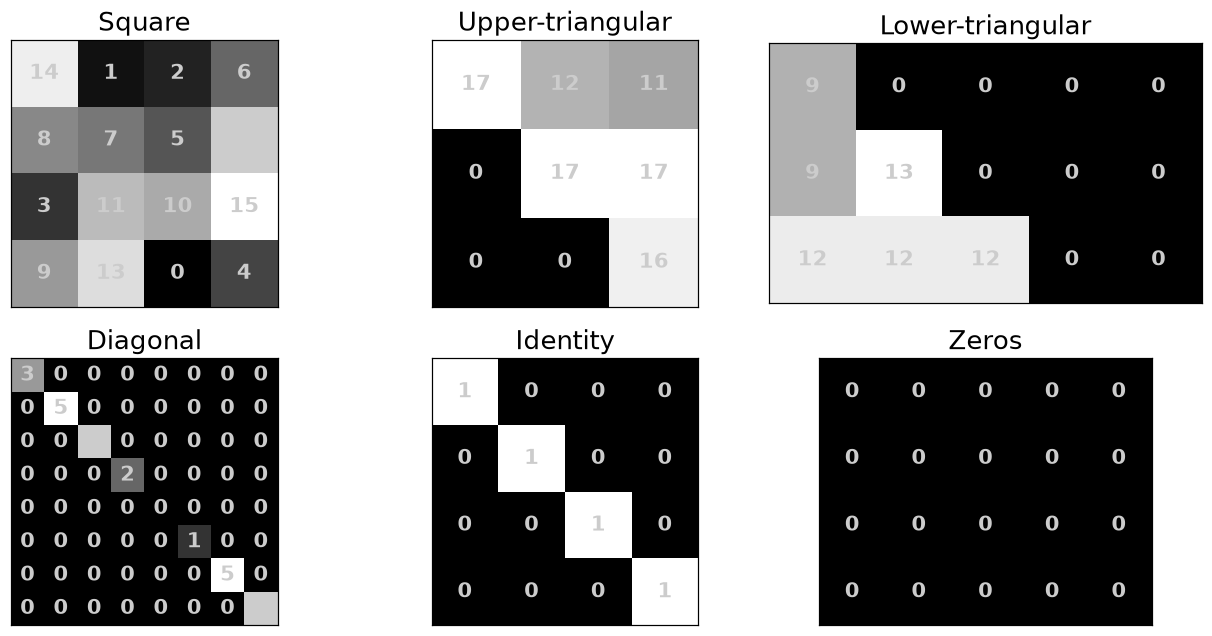

In [12]:
## create some matrices

# square
M1 = np.random.permutation(16).reshape(4,4)

# upper-triangular square
M2 = np.triu(np.random.randint(10,20,(3,3)))

# lower-triangular rectangular
M3 = np.tril(np.random.randint(8,16,(3,5)))

# diagonal
M4 = np.diag( np.random.randint(0,6,size=8) )

# identity
M5 = np.eye(4,dtype=int)

# zeros
M6 = np.zeros((4,5),dtype=int)

matrices  = [ M1,M2,M3,M4,M5,M6 ]
matLabels = [ 'Square','Upper-triangular','Lower-triangular','Diagonal','Identity','Zeros'  ]


_,axs = plt.subplots(2,3,figsize=(12,6))
axs = axs.flatten()

for mi,M in enumerate(matrices):
  axs[mi].imshow(M,cmap='gray',origin='upper',
                 vmin=np.min(M),vmax=np.max(M))
  axs[mi].set(xticks=[],yticks=[])
  axs[mi].set_title(matLabels[mi])
  
  # text labels
  for (j,i),num in np.ndenumerate(M):
    axs[mi].text(i,j,num,color=[.8,.8,.8],ha='center',va='center',fontweight='bold')



plt.savefig(ASSET / 'Figure_04_02.png',dpi=140)
plt.tight_layout()
plt.show()

### 특수 행렬의 성질

### 코드 04-12

- 원본: `original_py/LA4DS_ch04.py` 144–152행.

In [13]:
# matrix size parameters (called 'shape' in Python lingo)
Mrows = 4 # shape 0
Ncols = 6 # shape 1

# create the matrix!
A = np.random.randn(Mrows,Ncols)

# print out the matrix (rounding to facilitate visual inspection)
np.round(A,3)

Out[13]: 
array([[-1.832,  0.646, -0.334, -0.112,  0.151,  0.537],
       [ 0.746,  1.18 ,  1.114,  0.166, -0.139, -1.523],
       [-0.285, -0.803,  0.481,  0.461,  1.154, -1.412],
       [-0.44 ,  0.534, -0.722,  0.766,  0.092,  0.478]])


### 코드 04-13

- 원본: `original_py/LA4DS_ch04.py` 154–166행.

In [14]:
# Extract the triangular part of a dense matrix

M = 4
N = 6
A = np.random.randn(M,N)

# upper triangular
print('Upper triangular:\n')
print(np.triu(A))

# lower triangular
print('\n\nLower triangular:\n')
print(np.tril(A))

Upper triangular:

[[ 1.126046  0.725251  0.954782 -1.230372 -0.395382  0.663184]
 [ 0.        1.31446  -0.051953  1.685747  2.614493 -0.294304]
 [ 0.        0.        0.438054 -1.196189 -0.708118 -0.443579]
 [ 0.        0.        0.       -1.432085 -0.299351  0.073085]]


Lower triangular:

[[ 1.126046  0.        0.        0.        0.        0.      ]
 [ 1.990318  1.31446   0.        0.        0.        0.      ]
 [-0.257956  0.823851  0.438054  0.        0.        0.      ]
 [-1.031888  0.720566 -0.51555  -1.432085  0.        0.      ]]


### 코드 04-14

- 원본: `original_py/LA4DS_ch04.py` 168–178행.

In [15]:
# Diagonal

# input a matrix to get the diagonal elements
A = np.random.randn(5,5)
d = np.diag(A)
print('Input a matrix:\n',d)

# OR input a vector to create a diagonal matrix!
v = np.arange(1,6)
D = np.diag(v)
print('\n\nInput a vector:\n',D)

Input a matrix:
 [ 0.67268   0.403035  0.390651  0.848237 -1.526648]


Input a vector:
 [[1 0 0 0 0]
 [0 2 0 0 0]
 [0 0 3 0 0]
 [0 0 0 4 0]
 [0 0 0 0 5]]


### 코드 04-15

- 원본: `original_py/LA4DS_ch04.py` 180–185행.

In [16]:
# Identity and zeros matrices

# Note that you only specify one input
n = 4
I = np.eye(n)
print(f'The {n}x{n} identity matrix:\n',I)

The 4x4 identity matrix:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


### 코드 04-16

- 원본: `original_py/LA4DS_ch04.py` 188–195행.

In [17]:
# Zeros matrix

# Important: All shape parameters are given as one input (a tuple or list),
#            unlike np.random.randn()
n = 4
m = 5
I = np.zeros((n,m))
print(f'The {n}x{m} zeros matrix:\n',I)

The 4x5 zeros matrix:
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


### 행렬 덧셈

### 코드 04-17

- 원본: `original_py/LA4DS_ch04.py` 199–205행.

In [18]:
A = np.array([  [2,3,4],
                [1,2,4] ])

B = np.array([  [ 0, 3,1],
                [-1,-4,2] ])

print(A+B)

[[ 2  6  5]
 [ 0 -2  6]]


### 대각 이동

### 코드 04-18

- 원본: `original_py/LA4DS_ch04.py` 209–210행.

In [19]:
# Not shifting; broadcasting scalar addition
3 + np.eye(2)

Out[19]: 
array([[4., 3.],
       [3., 4.]])


### 코드 04-19

- 원본: `original_py/LA4DS_ch04.py` 212–231행.

In [20]:
# This is shifting:

# the matrix
A = np.array([ [4,5, 1],
               [0,1,11],
               [4,9, 7]  ])

# the scalar
s = 6

print('Original matrix:')
print(A), print(' ')

# as in the previous cell, this is broadcasting addition, not shifting
print('Broadcasting addition:')
print(A + s), print(' ')

# This is shifting
print('Shifting:')
print( A + s*np.eye(len(A)) )

Original matrix:
[[ 4  5  1]
 [ 0  1 11]
 [ 4  9  7]]
 
Broadcasting addition:
[[10 11  7]
 [ 6  7 17]
 [10 15 13]]
 
Shifting:
[[10.  5.  1.]
 [ 0.  7. 11.]
 [ 4.  9. 13.]]


### 스칼라 곱

### 코드 04-20

- 원본: `original_py/LA4DS_ch04.py` 235–236행.

In [21]:
print(A), print(' ')
print(s*A)

[[ 4  5  1]
 [ 0  1 11]
 [ 4  9  7]]
 
[[24 30  6]
 [ 0  6 66]
 [24 54 42]]


### 원소별 곱

### 코드 04-21

- 원본: `original_py/LA4DS_ch04.py` 240–251행.
- **보완**: 의도된 오류를 해당 예외 타입으로 처리하고 오류 메시지를 출력합니다.

In [22]:
try:
    # two random matrices
    A = np.random.randn(3,4)
    B = np.random.randn(3,4)

    # this is Hadamard multiplication
    A*B 

    # and so is this
    np.multiply(A,B)

    # this one is NOT Hadamard multiplication
    A@B
except ValueError as exc:
    print("학습용 예상 오류:", type(exc).__name__, str(exc))

학습용 예상 오류: ValueError matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 4)


### 행렬 곱

### 코드 04-22

- 원본: `original_py/LA4DS_ch04.py` 255–264행.
- **보완**: 의도된 오류를 해당 예외 타입으로 처리하고 오류 메시지를 출력합니다.

In [23]:
try:
    # Create a few matrices
    A = np.random.randn(3,6)
    B = np.random.randn(6,4)
    C = np.random.randn(6,4)

    # try some multiplications, and print out the shape of the product matrix
    print( (A@B).shape )
    print( np.dot(A,B).shape ) # same as above
    print( (B@C).shape )
    print( (A@C).shape )
except ValueError as exc:
    print("학습용 예상 오류:", type(exc).__name__, str(exc))

(3, 4)
(3, 4)
학습용 예상 오류: ValueError matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 6 is different from 4)


### 코드 04-23

- 원본: `original_py/LA4DS_ch04.py` 266–275행.

In [24]:
# Note/reminder:

# This is Hadamard (element-wise) multiplication:
print( np.multiply(B,C) ), print(' ')

# This is matrix multiplication
print( np.dot(B,C.T) )

# demonstration:
# np.dot(B,C.T)-B@C.T

[[-0.511784 -0.185465 -0.249684  0.774567]
 [ 0.043821  0.071776  1.317631 -0.031281]
 [-0.671383 -0.195949 -0.068835 -3.361441]
 [ 0.543132 -2.003759  0.067227  0.465437]
 [-0.001327 -0.0217    0.41298  -0.139949]
 [-0.503992 -0.236322  0.905995  0.197311]]
 
[[-0.172366 -1.457415 -4.506759  0.07571   2.897355  0.963426]
 [-3.075569  1.401947  1.17886  -2.085599 -2.845638  4.269313]
 [ 1.442424 -0.369157 -4.297608  2.433638 -0.341242  5.720964]
 [ 1.129669  1.760009  3.60205  -0.927963 -3.902241 -1.314809]
 [ 1.100649 -0.324448 -1.777118  0.991079  0.250003  1.102871]
 [ 0.484024  1.446786  3.027356 -0.114887 -3.207619  0.362992]]


### 행렬이 벡터를 움직이는 방법

### 코드 04-24

- 원본: `original_py/LA4DS_ch04.py` 279–294행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

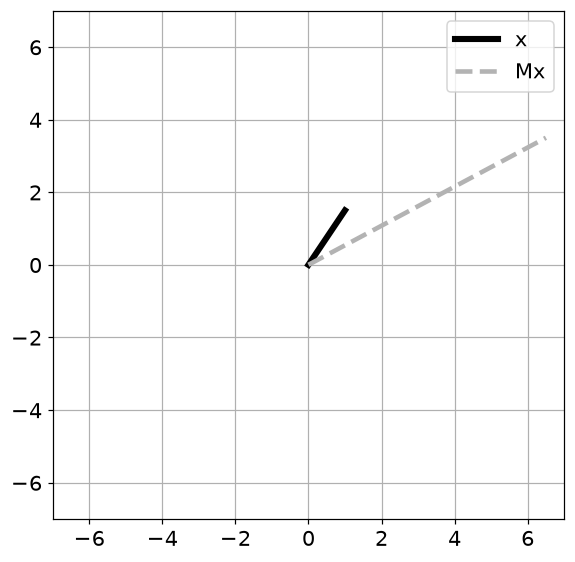

In [25]:
# some matrix
M  = np.array([ [2,3],[2,1] ])
x  = np.array([ [1,1.5] ]).T # transposed into a column vector!
Mx = M@x


plt.figure(figsize=(6,6))

plt.plot([0,x[0,0]],[0,x[1,0]],'k',linewidth=4,label='x')
plt.plot([0,Mx[0,0]],[0,Mx[1,0]],'--',linewidth=3,color=[.7,.7,.7],label='Mx')
plt.xlim([-7,7])
plt.ylim([-7,7])
plt.legend()
plt.grid()
plt.savefig(ASSET / 'Figure_04_05a.png',dpi=140)
plt.show()

### 코드 04-25

- 원본: `original_py/LA4DS_ch04.py` 296–311행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

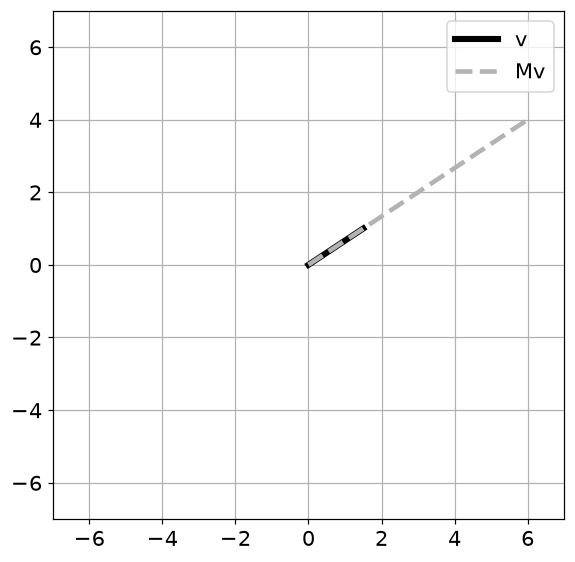

In [26]:
# some matrix
M  = np.array([ [2,3],[2,1] ])
v  = np.array([ [1.5,1] ]).T # transposed into a column vector!
Mv = M@v


plt.figure(figsize=(6,6))

plt.plot([0,v[0,0]],[0,v[1,0]],'k',linewidth=4,label='v')
plt.plot([0,Mv[0,0]],[0,Mv[1,0]],'--',linewidth=3,color=[.7,.7,.7],label='Mv')
plt.xlim([-7,7])
plt.ylim([-7,7])
plt.legend()
plt.grid()
plt.savefig(ASSET / 'Figure_04_05b.png',dpi=140)
plt.show()

### 전치

### 코드 04-26

- 원본: `original_py/LA4DS_ch04.py` 317–330행.

In [27]:
# A matrix to transpose
A = np.array([ [3,4,5],[1,2,3] ])

A_T1 = A.T # as method
A_T2 = np.transpose(A) # as function

# double-transpose
A_TT = A_T1.T 


# print them
print( A_T1 ), print(' ')
print( A_T2 ), print(' ')
print( A_TT )

[[3 1]
 [4 2]
 [5 3]]
 
[[3 1]
 [4 2]
 [5 3]]
 
[[3 4 5]
 [1 2 3]]


## 연습문제 1 · 행렬 원소 찾기

- **목표**: 수학의 1부터 세는 번호와 Python 인덱스를 구분합니다.
- **풀이 순서**: 0부터 11까지 3×4로 배치하고 두 번째 행·네 번째 열을 `[1,3]`으로 조회합니다.
- **결과 해석**: 값은 7입니다. 행을 먼저, 열을 다음에 쓰는 순서를 확인합니다.

### 코드 04-27

- 원본: `original_py/LA4DS_ch04.py` 336–345행.

In [28]:
# indexing

A = np.arange(12).reshape(3,4)
print(A)

# find the element in the 2nd row, 4th column
ri = 1
ci = 3

print(f'The matrix element at index ({ri+1},{ci+1}) is {A[ri,ci]}')

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
The matrix element at index (2,4) is 7


## 연습문제 2 · 부분행렬 자르기

- **목표**: 슬라이싱의 시작·끝·간격을 해석합니다.
- **풀이 순서**: 0부터 99까지 10×10 행렬을 만들고 `[0:5:1,0:5:1]`을 선택합니다.
- **결과 해석**: 왼쪽 위 5×5가 선택됩니다. 각 행 끝은 4,14,24,34,44입니다. 끝 인덱스 5는 포함되지 않습니다.

### 코드 04-28

- 원본: `original_py/LA4DS_ch04.py` 347–379행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

[[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29]
 [30 31 32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49]
 [50 51 52 53 54 55 56 57 58 59]
 [60 61 62 63 64 65 66 67 68 69]
 [70 71 72 73 74 75 76 77 78 79]
 [80 81 82 83 84 85 86 87 88 89]
 [90 91 92 93 94 95 96 97 98 99]]
 
[[ 0  1  2  3  4]
 [10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]
 [40 41 42 43 44]]


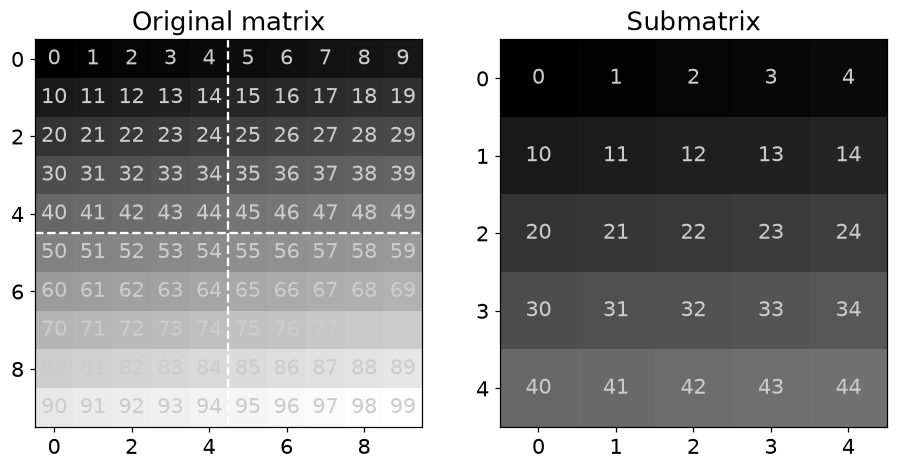

In [29]:
# Create the matrix
C = np.arange(100).reshape((10,10))

# extract submatrix
C_1 = C[0:5:1,0:5:1]

# here's what the matrices look like
print(C), print(' ')
print(C_1)



# visualize the matrices as maps
_,axs = plt.subplots(1,2,figsize=(10,5))

axs[0].imshow(C,cmap='gray',origin='upper',vmin=0,vmax=np.max(C))
axs[0].plot([4.5,4.5],[-.5,9.5],'w--')
axs[0].plot([-.5,9.5],[4.5,4.5],'w--')
axs[0].set_title('Original matrix')
# text labels
for (j,i),num in np.ndenumerate(C):
  axs[0].text(i,j,num,color=[.8,.8,.8],ha='center',va='center')


axs[1].imshow(C_1,cmap='gray',origin='upper',vmin=0,vmax=np.max(C))
axs[1].set_title('Submatrix')
# text labels
for (j,i),num in np.ndenumerate(C_1):
  axs[1].text(i,j,num,color=[.8,.8,.8],ha='center',va='center')


plt.savefig(ASSET / 'Figure_04_06.png',dpi=140)
plt.show()

## 연습문제 3 · 블록 재배치

- **목표**: 작은 행렬을 조립해 큰 행렬을 구성합니다.
- **풀이 순서**: 10×10을 네 개의 5×5 블록으로 나눈 후 hstack으로 가로 연결, vstack으로 세로 연결합니다.
- **결과 해석**: 블록 위치는 바뀌지만 각 블록 내부 순서는 그대로입니다. 전체 원소를 뒤집는 연산과 다릅니다.

### 코드 04-29

- 원본: `original_py/LA4DS_ch04.py` 381–413행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

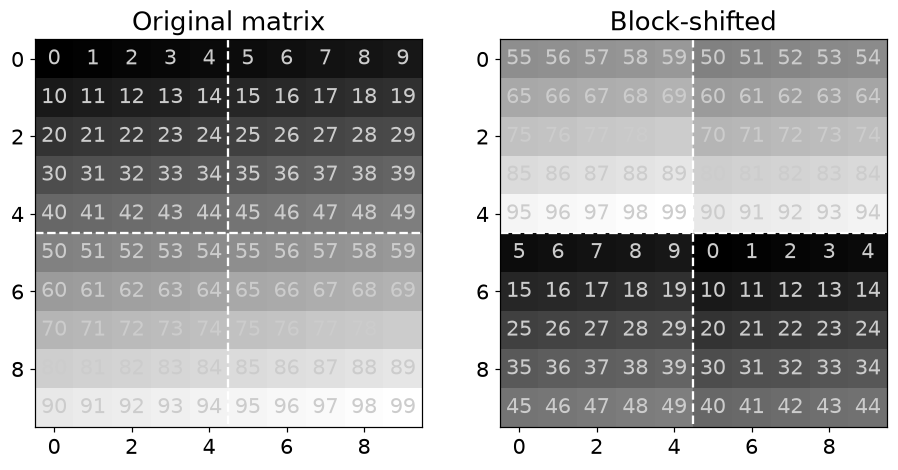

In [30]:
# cut it into blocks
C_1 = C[0:5:1,0:5:1]
C_2 = C[0:5:1,5:10:1]
C_3 = C[5:10:1,0:5:1]
C_4 = C[5:10:1,5:10:1]

# rearrange the blocks
newMatrix = np.vstack( (np.hstack((C_4,C_3)),
                        np.hstack((C_2,C_1))) )


# visualize the matrices
_,axs = plt.subplots(1,2,figsize=(10,5))

axs[0].imshow(C,cmap='gray',origin='upper',vmin=0,vmax=np.max(C))
axs[0].plot([4.5,4.5],[-.5,9.5],'w--')
axs[0].plot([-.5,9.5],[4.5,4.5],'w--')
axs[0].set_title('Original matrix')
# text labels
for (j,i),num in np.ndenumerate(C):
  axs[0].text(i,j,num,color=[.8,.8,.8],ha='center',va='center')


axs[1].imshow(newMatrix,cmap='gray',origin='upper',vmin=0,vmax=np.max(C))
axs[1].plot([4.5,4.5],[-.5,9.5],'w--')
axs[1].plot([-.5,9.5],[4.5,4.5],'w--')
axs[1].set_title('Block-shifted')
# text labels
for (j,i),num in np.ndenumerate(newMatrix):
  axs[1].text(i,j,num,color=[.8,.8,.8],ha='center',va='center')

plt.savefig(ASSET / 'Figure_04_07.png',dpi=140)
plt.show()

## 연습문제 4 · 덧셈 함수 구현

- **목표**: 행렬 덧셈의 모양 조건과 이중 반복문을 확인합니다.
- **풀이 순서**: 두 shape가 같은지 검사하고 각 위치의 값을 더합니다. 영행렬과 1행렬로 테스트합니다.
- **결과 해석**: 결과는 같은 모양의 1행렬입니다. 모양 불일치는 문자열을 raise할 수 없으므로 ValueError로 고쳤습니다.

### 코드 04-30

- 원본: `original_py/LA4DS_ch04.py` 415–436행.
- **보완**: 문자열 raise를 ValueError로 수정했습니다.

In [31]:
def addMatrices(A,B):

  # check that both matrices have the same size
  if A.shape != B.shape:
    raise ValueError('Matrices must be the same size!')

  # initialize sum matrix
  C = np.zeros(A.shape)

  # sum!
  for i in range(A.shape[0]):
    for j in range(A.shape[1]):
      C[i,j] = A[i,j] + B[i,j]
  
  return C


# test the function
M1 = np.zeros((6,4))
M2 = np.ones((6,4))

addMatrices(M1,M2)

Out[31]: 
array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])


## 연습문제 5 · 스칼라 분배법칙

- **목표**: $s(A+B)=sA+sB$를 검증합니다.
- **풀이 순서**: 세 표현을 계산한 뒤 원본처럼 $2E_1-E_2-E_3$을 출력합니다.
- **결과 해석**: 0 근처 행렬이 나옵니다. 이 조합 검사는 오차 상쇄가 가능하므로 더 엄밀한 검증은 각 쌍에 allclose를 적용하는 것입니다.

### 코드 04-31

- 원본: `original_py/LA4DS_ch04.py` 439–454행.

In [32]:
# create random matrices and a scalar
A = np.random.randn(3,4)
B = np.random.randn(3,4)
s = np.random.randn()

# equations shown in the text
expr1 = s*(A+B)
expr2 = s*A + s*B
expr3 = A*s + B*s


# There are a few ways to test for 3-way equality. 
# My choice below is that if x=y=z, then 2x-y-z=0.

# print out, rounded to 8 digits after the decimal point
print(np.round(2*expr1 - expr2 - expr3,8))

[[ 0.  0.  0. -0.]
 [ 0. -0.  0. -0.]
 [ 0.  0.  0.  0.]]


## 연습문제 6 · 행렬 곱 구현

- **목표**: 출력 원소 하나가 행과 열의 내적임을 이해합니다.
- **풀이 순서**: 4×6 A와 6×4 B를 만들고 각 행·열 내적을 4×4 C에 저장합니다. `A@B`와 isclose로 비교합니다.
- **결과 해석**: 모든 항이 True이면 구현이 맞습니다. 안쪽 차원 6이 합의 범위이고 바깥 차원 4×4가 결과 크기입니다.

### 코드 04-32

- 원본: `original_py/LA4DS_ch04.py` 458–476행.

In [33]:
# generate two matrices
m = 4
n = 6
A = np.random.randn(m,n);
B = np.random.randn(n,m)

# build up the product matrix element-wise
C1 = np.zeros((m,m))
for rowi in range(m):
  for coli in range(m):
    C1[rowi,coli] = np.dot( A[rowi,:],B[:,coli] )
    


# implement matrix multiplication directly
C2 = A@B

# compare the results (using isclose(); results should be a matrix of TRUEs)
np.isclose( C1,C2 )

Out[33]: 
array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])


## 연습문제 7 · 여러 곱의 전치

- **목표**: 전치할 때 곱셈 순서가 뒤집힘을 확인합니다.
- **풀이 순서**: 2×6, 6×3, 3×5, 5×2 행렬을 곱해 전치한 결과와 역순 전치 곱을 비교합니다.
- **결과 해석**: 차이는 반올림 오차 정도입니다. 같은 순서로 전치한 곱은 차원부터 맞지 않을 수 있습니다.

### 코드 04-33

- 원본: `original_py/LA4DS_ch04.py` 480–492행.

In [34]:
# Create the matrices
L = np.random.randn(2,6)
I = np.random.randn(6,3)
V = np.random.randn(3,5)
E = np.random.randn(5,2)

# multiplications indicated in the instructions
res1 = ( L@I@V@E ).T
# res2 = L.T @ I.T @ V.T @ E.T
res3 = E.T @ V.T @ I.T @ L.T

# show that res1 and res3 are the same (within rounding error tolerance)
print(res1-res3)

[[-0. -0.]
 [ 0.  0.]]


## 연습문제 8 · 대칭 판정 함수

- **목표**: $S-S^T$의 오차로 대칭성을 판단합니다.
- **풀이 순서**: 차이 원소의 제곱합이 작은지 검사합니다. 임의 정사각행렬과 $A^TA$를 대조합니다.
- **결과 해석**: 보통 False와 True가 나옵니다. 고정 임계값은 행렬 크기·스케일에 민감하므로 실무에서는 상대 허용오차도 고려합니다.

### 코드 04-34

- 원본: `original_py/LA4DS_ch04.py` 496–508행.

In [35]:
def isMatrixSymmetric(S):
  
  # difference between matrix and its transpose
  D = S-S.T

  # check whether sum of squared errors (SSE) is smaller than a threshold
  sse = np.sum(D**2)

  # output TRUE if sse is tiny; FALSE means the matrix is asymmetric
  return sse<10**-15

# note: There are many other ways you could solve this. 
# If you want to explore different methods, consider np.all() or np.isclose()

### 코드 04-35

- 원본: `original_py/LA4DS_ch04.py` 510–516행.

In [36]:
# create symmetric and nonsymmetric matrices
A = np.random.randn(4,4)
AtA = A.T@A

# test!
print(isMatrixSymmetric(A))
print(isMatrixSymmetric(AtA))

False
True


## 연습문제 9 · 덧셈으로 대칭 만들기

- **목표**: $(A+A^T)/2$가 대칭임을 증명합니다.
- **풀이 순서**: 임의 A와 전치를 평균낸 뒤 앞의 판정 함수를 적용합니다.
- **결과 해석**: 대칭 판정은 True입니다. $A^TA$와 달리 음의 고윳값을 가질 수 있으므로 양의 준정부호까지 보장하지 않습니다.

### 코드 04-36

- 원본: `original_py/LA4DS_ch04.py` 520–526행.

In [37]:
# create symmetric and nonsymmetric matrices
A = np.random.randn(4,4)
AtA = (A + A.T) / 2 # additive method!

# test!
print(isMatrixSymmetric(A))
print(isMatrixSymmetric(AtA))

False
True


## 연습문제 10 · 행렬 곱으로 span 그리기

- **목표**: 열의 선형결합을 하나의 행렬 곱으로 표현합니다.
- **풀이 순서**: 3×2 행렬의 두 열에 난수 가중치를 적용해 3차원 점들을 생성합니다. 정적 그림과 회전 가능한 HTML을 제공합니다.
- **결과 해석**: 두 독립 열이면 평면을 이룹니다. 한 열을 다른 열의 배수로 바꾸면 랭크 1의 직선으로 줄어듭니다.

### 코드 04-37

- 원본: `original_py/LA4DS_ch04.py` 530–553행.
- **보완**: Plotly 3차원 그림은 HTML로 보존하고, Markdown용 정적 3차원 산점도를 추가했습니다.

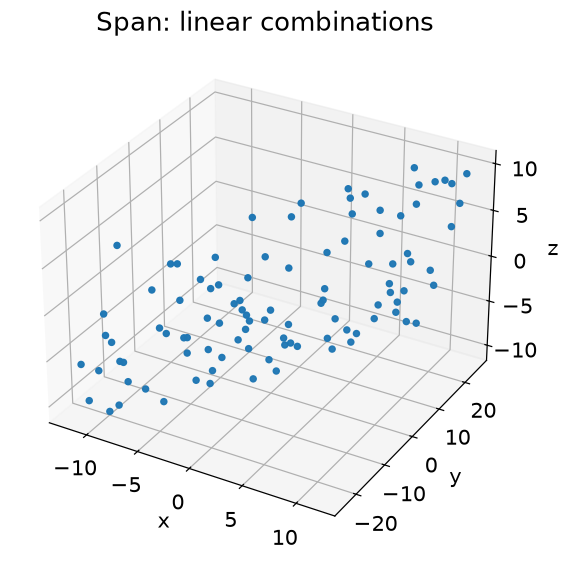

In [38]:
import plotly.graph_objects as go

# As a matrix with two columns in R3, instead of two separate vectors
A = np.array( [ [3,0],
                [5,2],
                [1,2] ] )

# uncomment the line below
# A = np.array( [ [3,1.5],
#                 [5,2.5],
#                 [1, .5] ] )


xlim = [-4,4]
scalars = np.random.uniform(low=xlim[0],high=xlim[1],size=(100,2))

# create random points
points = np.zeros((100,3))
for i in range(len(scalars)):
  points[i,:] = A@scalars[i]

# draw the dots in the figure
fig = go.Figure( data=[go.Scatter3d(x=points[:,0], y=points[:,1], z=points[:,2], mode='markers')])
fig.write_html(str(ASSET / 'interactive_3d.html'), include_plotlyjs=True)
ax = plt.figure(figsize=(7, 6)).add_subplot(projection='3d')
ax.scatter(points[:,0], points[:,1], points[:,2], s=15)
ax.set(xlabel='x', ylabel='y', zlabel='z', title='Span: linear combinations')
plt.show()

## 연습문제 11 · 대각행렬의 왼쪽·오른쪽 곱

- **목표**: 행 스케일링과 열 스케일링을 구분합니다.
- **풀이 순서**: 1행렬 O에 대각 D를 앞·뒤에서 곱합니다. 또 $S=\sqrt D$로 SOS를 계산합니다.
- **결과 해석**: DO는 행별 배율, OD는 열별 배율입니다. SOS의 (i,j)원소는 $\sqrt{d_i d_j}$가 됩니다.

### 코드 04-38

- 원본: `original_py/LA4DS_ch04.py` 557–592행.

In [39]:
n = 4

# create "base" matrices
O = np.ones((n,n))
D = np.diag(np.arange(1,n+1)**2)
S = np.sqrt(D)

# pre- and post-multiply
pre = D@O
pst = O@D

# and both
both = S@O@S



# print out the "base" matrices
print('Ones matrix:')
print(O), print(' ')

print('Diagonal matrix:')
print(D), print(' ')

print('Sqrt-diagonal matrix:')
print(S), print(' ')



print('Pre-multiply by diagonal:')
print(pre), print(' ')

print('Post-multiply by diagonal:')
print(pst), print(' ')

print('Pre- and post-multiply by sqrt-diagonal:')
print(both)

Ones matrix:
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]
 
Diagonal matrix:
[[ 1  0  0  0]
 [ 0  4  0  0]
 [ 0  0  9  0]
 [ 0  0  0 16]]
 
Sqrt-diagonal matrix:
[[1. 0. 0. 0.]
 [0. 2. 0. 0.]
 [0. 0. 3. 0.]
 [0. 0. 0. 4.]]
 
Pre-multiply by diagonal:
[[ 1.  1.  1.  1.]
 [ 4.  4.  4.  4.]
 [ 9.  9.  9.  9.]
 [16. 16. 16. 16.]]
 
Post-multiply by diagonal:
[[ 1.  4.  9. 16.]
 [ 1.  4.  9. 16.]
 [ 1.  4.  9. 16.]
 [ 1.  4.  9. 16.]]
 
Pre- and post-multiply by sqrt-diagonal:
[[ 1.  2.  3.  4.]
 [ 2.  4.  6.  8.]
 [ 3.  6.  9. 12.]
 [ 4.  8. 12. 16.]]


## 연습문제 12 · 대각행렬의 두 곱

- **목표**: 특수한 경우 원소별 곱과 행렬 곱이 같음을 확인합니다.
- **풀이 순서**: 두 대각행렬에 `*`와 `@`를 각각 적용하고 차이를 구합니다.
- **결과 해석**: 0행렬이 나옵니다. 대각 밖의 성분이 모두 0이기 때문이며 일반 행렬로 확대할 수 없는 성질입니다.

### 코드 04-39

- 원본: `original_py/LA4DS_ch04.py` 596–606행.

In [40]:
# Create two diagonal matrices
N = 5
D1 = np.diag( np.random.randn(N) )
D2 = np.diag( np.random.randn(N) )

# two forms of multiplication
hadamard = D1*D2
standard = D1@D2

# compare them
hadamard - standard

Out[40]: 
array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])


## 핵심 결과 다시 확인하기

- 아래는 원본과 별도로 추가한 작은 검증 예제입니다.
- `assert`가 통과하면 해당 수학적 관계가 지정한 수치 허용오차 안에서 성립한 것입니다.
- 큰 예제의 숫자를 외우기보다 이 관계가 왜 성립하는지 설명해 보세요.

In [41]:
_A=np.array([[1,2],[3,4]]); _B=np.array([[2,0],[1,2]])
print('원소별 곱:\n',_A*_B); print('행렬 곱:\n',_A@_B)
assert np.array_equal(_A@_B,[[4,4],[10,8]])
assert np.array_equal((_A@_B).T,_B.T@_A.T)
print('전치 곱 공식 검증: 통과')


원소별 곱:
 [[2 0]
 [3 8]]
행렬 곱:
 [[ 4  4]
 [10  8]]
전치 곱 공식 검증: 통과
